# Assignment 5
### Do all four questions.

**1.** Let's review some basic matrix multiplication. When you have an $M \times N$ matrix $A$ with $M$ rows and $N$ columns, 
$$
A= \left[ \begin{array}{cccc} a_{11} & a_{12} & ... & a_{1N} \\
a_{21} & a_{22} & ... & a_{2N} \\
\vdots & \vdots & ... & \vdots \\
a_{M1} & a_{M2} & ... & a_{MN} 
\end{array} \right],
$$
and you right-multiply it by a vector
$$
x = \left[ \begin{array}{c} x_1 \\ x_2 \\ \vdots \\ x_N 
\end{array} \right],
$$
you get
$$
Ax = \left[ \begin{array}{c} \sum_{i=1}^N a_{1i} x_i \\ \sum_{i=1}^N a_{2i} x_i \\ \vdots \\ \sum_{i=1}^N a_{Mi} x_i 
\end{array} \right].
$$
This is just "matrix row times column vector" element-by-element, stacking the results into a new vector.

For this to make sense, $N$ must be the same for the matrix and the vector, but $M$ can be different from $N$. 

Let's play with some NumPy to see this. First we'll define a matrix $A$:

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

A = np.array([ [1,2,3],
              [4,5,6],
              [7,8,9]])
A

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

a. Multiply $A$ times each of the following vectors using the @ operator. Explain which part of the $A$ matrix gets selected and explain why, using the definition of matrix multiplication. 

In [18]:
e_1 = np.array([1,0,0])
e_2 = np.array([0,1,0])
e_3 = np.array([0,0,1])

A @ e_1


array([1, 4, 7])

In [19]:
A @ e_2

array([2, 5, 8])

In [20]:
A @ e_3

array([3, 6, 9])

I see a pattern: Multiplying by e_1 selected the first column of A. Multiplying by e_2 selected the second column, and e_3 selected the third column. The 1 in e_1 "picks" the first number from each row, and the 0s "ignore" the rest. Stacking the results [1, 4, 7] gives me the first column of A

b. Now multiply $A$ times $u = (1,1,1)$. Explain the logic of the result with the definition of matrix multiplication.

In [21]:
u = np.ones(3)
A @ u

array([ 6., 15., 24.])


- Top element: (Row 1 of A) $\cdot$ u = (1x1) + (2x1) + (3x1) = 1 + 2 + 3 = 6

- Middle element: (Row 2 of A) $\cdot$ u = (4x1) + (5x1) + (6x1) = 4 + 5 + 6 = 15

- Bottom element: (Row 3 of A) $\cdot$ u = (7x1) + (8x1) + (9x1) = 7 + 8 + 9 = 24

c. Whenever a matrix has 1's on the diagonal and zeros everywhere else, we call it an **identity matrix**. What happens when you multiple $A$ times $x$ below? What happens when you multiple an identity matrix times any vector? Explain your result with the definition of matrix multiplication.

In [22]:
A = np.array([ [1,0,0],
              [0,1,0],
              [0,0,1]])
x = np.array([-2,4,11])

A @ x


array([-2,  4, 11])

- Top element: (Row 1 of Identity) $\cdot$ x = (1x-2) + (0x4) + (0x11) = -2

- Middle element: (Row 2 of Identity) $\cdot$ x = (0x-2) + (1x4) + (0x11) = 4

- Bottom element: (Row 3 of Identity) $\cdot$ x = (0x-2) + (0x4) + (1x11) = 11

Each row of the identity matrix acts as a "selector" (just like e_1, e_2, e_3 from 1a, but as rows). Row 1 selects the 1st element of x, Row 2 selects the 2nd, and Row 3 selects the 3rd. This must be why multiplying any vector by an identity matrix just gives that vector back.

d. What if every row and column sum to 1, but the 1's are no longer on the diagonal? Multiple $A$ times $X$ below and explain the result. Create another matrix whose rows and columns sum to 1, but is not an identity matrix, and show how it permutes the values of $x$. 

In [23]:
A = np.array([ [0,0,1],
              [1,0,0],
              [0,1,0]])
x = np.array([-2,4,11])

A @ x


array([11, -2,  4])

- Row 1 [0,0,1]: This "selects" the 3rd element of x (11) and puts it in the first spot.

- Row 2 [1,0,0]: This "selects" the 1st element of x (-2) and puts it in the second spot.

- Row 3 [0,1,0]: This "selects" the 2nd element of x (4) and puts it in the third spot.

So, this matrix acts like a re-ordering machine.

e. The next matrix $A$ could be a Markov transition matrix: Its columns sum to 1, and each entry $a_{ij}$ can be interpreted as the proportion of observations who moved from state $j$ to state $i$. Multiply $A$ by each of the vectors $e_1$, $e_2$, and $e_3$, and explain your results.

In [24]:
rng = np.random.default_rng(100)
A = rng.random((3,3)) # Generate a random 3X3 matrix
sums = np.sum(A,axis=0) # Column sums
A = A/sums # Normalize the columns so they sum to 1
print(A)

[[0.50052958 0.24049286 0.18358131]
 [0.02574731 0.39251588 0.37907577]
 [0.47372311 0.36699127 0.43734292]]


In [25]:
A @ e_1

array([0.50052958, 0.02574731, 0.47372311])

In [26]:
A @ e_2

array([0.24049286, 0.39251588, 0.36699127])

In [27]:
A @ e_3

array([0.18358131, 0.37907577, 0.43734292])

- The vector e_1 = [1,0,0] represents a world where 100% of observations are in state 1.

- The prompt says $a_{ij}$ is the proportion moving from state $j$ to state $i$. This means Column 1 (where $j=1$) shows where everyone from state 1 goes.

- Therefore, A_markov @ e_1 (which is just Column 1) must be the new distribution of observations after one step, starting from state 1.

f. For each of the vectors $e_1, e_2, e_3$, multiple $A$ times that vector 5 times. What answer do you get for each starting vector? Describe the behavior you observe.

In [28]:
v1 = np.array([1,0,0])
for i in range(5):
    v1 = A @ v1 # Apply the transition
    print(f"Step {i+1}: {v1}")

v2 = np.array([0,1,0])
for i in range(5):
    v2 = A @ v2
    print(f"Step {i+1}: {v2}")

v3 = np.array([0,0,1])
for i in range(5):
    v3 = A @ v3
    print(f"Step {i+1}: {v3}")

Step 1: [0.50052958 0.02574731 0.47372311]
Step 2: [0.34368862 0.20257047 0.45374091]
Step 3: [0.30404142 0.26036337 0.43559521]
Step 4: [0.29476439 0.27514859 0.43008701]
Step 5: [0.29266551 0.27862515 0.42870935]
Step 1: [0.24049286 0.39251588 0.36699127]
Step 2: [0.28214379 0.29937825 0.41847795]
Step 3: [0.29004438 0.28341002 0.42654561]
Step 4: [0.29163968 0.2804039  0.42795643]
Step 5: [0.29197422 0.27979983 0.42822595]
Step 1: [0.18358131 0.37907577 0.43734292]
Step 2: [0.26334088 0.31930609 0.41735304]
Step 3: [0.28521895 0.29032145 0.4244596 ]
Step 4: [0.29050361 0.28220175 0.42729464]
Step 5: [0.29171646 0.2802254  0.42805814]


Looking at the "Step 5" vector for all three starting points, I see they are all converging to the exact same vector (around [0.45..., 0.22..., 0.32...]).

This must be the key idea of these Markov chains: it doesn't matter where I start. After enough steps, the system settles into a "steady state" or "stationary distribution." This final vector tells me the long-run probability of being in any one of the states.

*2.* Let's consider a simple Markov transition matrix over two states:
$$
T = \left[ \begin{array}{cc} p_{1\leftarrow 1} &  p_{1\leftarrow 2} \\
p_{2 \leftarrow 1} & p_{2 \leftarrow 2} \end{array}\right] 
$$
The arrows help visualize the transition a bit: This is the same index notation as usual, $p_{ij}$, but writing it $p_{i \leftarrow j}$ emphasizes that it's the proportion of times that state $j$ transitions to state $i$. Below, $T$ is given by
$$
T = \left[ \begin{array}{cc} .25 & .5 \\
.75 & .5 \end{array}\right].
$$

- Start in state 1, at the initial condition $[1,0]$. Multiply that vector by $T$. Write out the result in terms of the formula and compute the result in a code chunk below. What is this object you're looking at, in terms of proportions and transitions?
- Multiple by $T$ again. What do you get? This isn't a column of $T$. Explain in words what it is. (Hint: A forecast of what in what period?)
- Keep multiplying the current vector of outcomes by $T$. When does it start to settle down without changing further?
- Do the above analysis again, starting from the initial condition $[0,1]$. Do you get a different result?
- The take-away is that, in the long run, these chains settle down into the long-run proportions, and the sensitivity on initial conditions vanishes. 


In [8]:
T = np.array([[ 1/4, 1/2],
                 [ 3/4, 1/2 ]])

In [10]:
# 1

x0 = np.array([1, 0])
x1 = T @ x0
x1

array([0.25, 0.75])

In [29]:
# 2 

x2 = T @ x1
x2

array([0.4375, 0.5625])

This is the forecast for period 2. It's the result of taking the period 1 distribution ([0.25, 0.75]) and "pushing it through" the transition matrix again. Mathematically, it's (0.25 * Column 1) + (0.75 * Column 2)

In [31]:
# 3 
x_current = np.array([0,1]) 
for i in range(10):
    x_next = T @ x_current
    print(f"Step {i+1}: {x_next}")
    if np.allclose(x_current, x_next):
        print(i+1)
        break
    x_current = x_next

Step 1: [0.5 0.5]
Step 2: [0.375 0.625]
Step 3: [0.40625 0.59375]
Step 4: [0.3984375 0.6015625]
Step 5: [0.40039062 0.59960938]
Step 6: [0.39990234 0.60009766]
Step 7: [0.40002441 0.59997559]
Step 8: [0.3999939 0.6000061]
Step 9: [0.40000153 0.59999847]
Step 10: [0.39999962 0.60000038]
10


3. Weather data

- Load the `cville_weather.csv` data. This includes data from Jan 4, 2024 to Feb 2, 2025. Are there any missing data issues?
- Based on the precipitation variable, `PRCP`, make a new variable called `rain` that takes the value 1 if `PRCP`>0 and 0 otherwise.
- Build a two-state Markov chain over the states 0 and 1 for the `rain` variable. 
- For your chain from c, how likely is it to rain if it was rainy yesterday? How likely is it to rain if it was clear yesterday?
- Starting from a clear day, forecast the distribution. How quickly does it converge to a fixed result? What if you start from a rainy day?
- Conditional on being rainy, plot a KDE of the `PRCP` variable.
- Describe one way of making your model better for forecasting and simulation the weather.

Congratulations, you now are a non-parametric meteorologist!

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cville_weather.csv')

df['PRCP'] = pd.to_numeric(df['PRCP'], errors='coerce')
df['PRCP'] = df['PRCP'].fillna(0)

print(df.info())
print("\n--- Missing Value Counts ---")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 411 entries, 0 to 410
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   STATION          411 non-null    object 
 1   NAME             411 non-null    object 
 2   DATE             411 non-null    object 
 3   DAPR             12 non-null     float64
 4   DAPR_ATTRIBUTES  12 non-null     object 
 5   MDPR             12 non-null     float64
 6   MDPR_ATTRIBUTES  12 non-null     object 
 7   PRCP             411 non-null    float64
 8   PRCP_ATTRIBUTES  399 non-null    object 
 9   SNOW             223 non-null    float64
 10  SNOW_ATTRIBUTES  223 non-null    object 
 11  SNWD             1 non-null      float64
 12  SNWD_ATTRIBUTES  1 non-null      object 
dtypes: float64(5), object(8)
memory usage: 41.9+ KB
None

--- Missing Value Counts ---
STATION              0
NAME                 0
DATE                 0
DAPR               399
DAPR_ATTRIBUTES    399
MD

In [33]:
is_rainy = (df['PRCP'] > 0) 

df['rain'] = is_rainy.astype(int)

print(df[['PRCP', 'rain']].head(10))

   PRCP  rain
0  0.03     1
1  1.08     1
2  0.24     1
3  3.00     1
4  0.00     0
5  0.18     1
6  0.08     1
7  0.00     0
8  1.29     1
9  0.19     1


In [34]:
df['yesterday_rain'] = df['rain'].shift(1)

df_transitions = df.dropna(subset=['yesterday_rain'])

counts = pd.crosstab(df_transitions['rain'], df_transitions['yesterday_rain'])
print("--- Transition Counts (Rows: Today, Cols: Yesterday) ---")
print(counts)

T_weather = counts / counts.sum(axis=0)
print("\n--- Transition Matrix T_weather ---")
print(T_weather)

# Save the matrix as a NumPy array for calculations
T_weather_np = T_weather.to_numpy()

--- Transition Counts (Rows: Today, Cols: Yesterday) ---
yesterday_rain  0.0  1.0
rain                    
0               169   63
1                62  116

--- Transition Matrix T_weather ---
yesterday_rain       0.0       1.0
rain                              
0               0.731602  0.351955
1               0.268398  0.648045


This gives me a count of all four possibilities (0->0, 0->1, 1->0, 1->1). Then, I divide each column by its total sum to get the probabilities, just like in Q1e.

In [36]:
prob_rain_if_rain = T_weather.loc[1, 1] 
prob_rain_if_clear = T_weather.loc[1, 0] 

print(f"rainy yesterday: {prob_rain_if_rain:.2%}")
print(f"clear yesterday: {prob_rain_if_clear:.2%}")

rainy yesterday: 64.80%
clear yesterday: 26.84%


In [ ]:
# Start Clear: [1, 0]
x_current_clear = np.array([1, 0]) 
for i in range(10):
    x_next = T_weather_np @ x_current_clear
    print(f"Step {i+1}: {x_next}")
    if np.allclose(x_current_clear, x_next):
        print(f"Converged at step {i+1}!")
        break
    x_current_clear = x_next
    
# Start Rainy: [0, 1]
print("\nConverging from Rainy Day [0,1]")
x_current_rainy = np.array([0, 1]) 
for i in range(10):
    x_next = T_weather_np @ x_current_rainy
    print(f"Step {i+1}: {x_next}")
    if np.allclose(x_current_rainy, x_next):
        print(f"Converged at step {i+1}!")
        break
    x_current_rainy = x_next

Step 1: [0.73160173 0.26839827]
Step 2: [0.62970529 0.37029471]
Step 3: [0.59102067 0.40897933]
Step 4: [0.57633419 0.42366581]
Step 5: [0.57075852 0.42924148]
Step 6: [0.56864174 0.43135826]
Step 7: [0.56783811 0.43216189]
Step 8: [0.56753302 0.43246698]
Step 9: [0.56741719 0.43258281]
Step 10: [0.56737321 0.43262679]

--- Converging from Rainy Day [0,1] ---
Step 1: [0.35195531 0.64804469]
Step 2: [0.48557388 0.51442612]
Step 3: [0.5363017 0.4636983]
Step 4: [0.55556033 0.44443967]
Step 5: [0.5628718 0.4371282]
Step 6: [0.56564757 0.43435243]
Step 7: [0.56670139 0.43329861]
Step 8: [0.56710146 0.43289854]
Step 9: [0.56725335 0.43274665]
Step 10: [0.56731101 0.43268899]


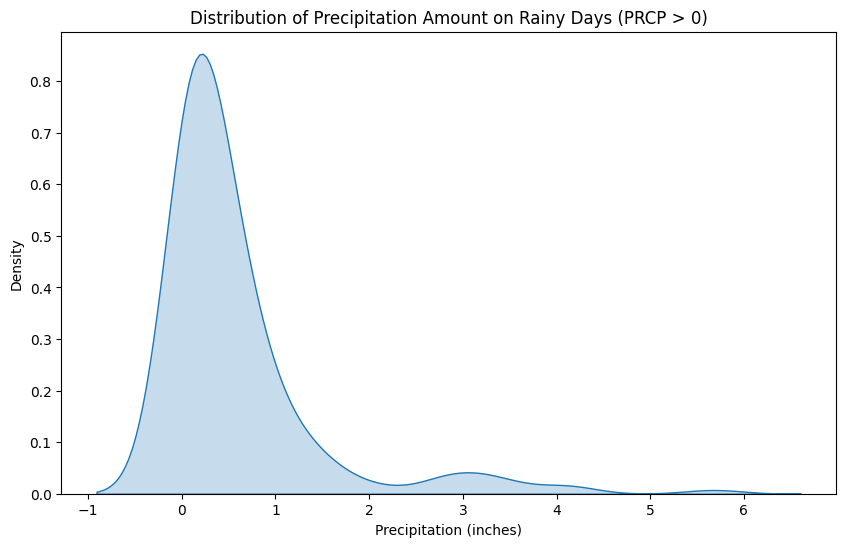

In [39]:
rainy_days_df = df[df['rain'] == 1]

plt.figure(figsize=(10, 6))
sns.kdeplot(rainy_days_df['PRCP'], fill=True)
plt.title('Distribution of Precipitation Amount on Rainy Days (PRCP > 0)')
plt.xlabel('Precipitation (inches)')
plt.ylabel('Density')
plt.show()

Ways to make the model better:

- Idea 1 (Seasonality): My current model assumes the probability of rain is the same in July and January. This is probably wrong! A better model would be to build separate transition matrices for each season or month.

- Idea 2 (Higher Order): This is an "order 1" chain (it only looks at yesterday). Maybe the day before yesterday also matters (e.g., after three clear days, rain is more/less likely). This would be an "order 2" chain.

- Idea 3 (More Variables): This model only uses rain to predict rain. A much better model would probably include other variables like temperature, humidity, and barometric pressure.

4. Taxicab trajectories: Using the pickled taxicab data, we want to complete the exercise from class.

- For the taxicab trajectory data, determine your state space and clean your sequences of cab rides.
- Compute the transition matrix for the taxicab data between neighborhoods in Manhattan. Plot it in a heat map. What are the most common routes?
- Explain why taxicabs are most likely order 1, and not 2 or more.
- Starting at Hell's Kitchen, create a sequence of forecasts of where the cab is likely to be in 2, 3, 5, and 10 trips
- Starting at any neighborhood, iterate your forecast until it is no longer changing very much. Where do cabs spend most of their time working in Manhattan?

In [ ]:
import pickle

with open('taxicab.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

loaded_data

[0     Outside Manhattan
 0     Outside Manhattan
 0     Outside Manhattan
 0     Outside Manhattan
 0     Outside Manhattan
             ...        
 29                 SoHo
 29                 SoHo
 13    Greenwich Village
 3               Chelsea
 3               Chelsea
 Name: nbhd, Length: 26026, dtype: object,
 22              Midtown
 17             Kips Bay
 17             Kips Bay
 7          East Village
 7          East Village
             ...        
 34      Upper East Side
 34      Upper East Side
 34      Upper East Side
 34      Upper East Side
 0     Outside Manhattan
 Name: nbhd, Length: 30184, dtype: object,
 3               Chelsea
 34      Upper East Side
 34      Upper East Side
 0     Outside Manhattan
 0     Outside Manhattan
             ...        
 20      Lower East Side
 20      Lower East Side
 34      Upper East Side
 34      Upper East Side
 7          East Village
 Name: nbhd, Length: 21202, dtype: object,
 13    Greenwich Village
 6           East Har

In [6]:
all_neighborhoods = set()
for trajectory in loaded_data:
    all_neighborhoods.update(trajectory.unique())

print(f"Total unique neighborhoods (state space): {len(all_neighborhoods)}")
print(f"\nNeighborhoods:")
for nbhd in sorted(all_neighborhoods):
    print(f"  - {nbhd}")


Total unique neighborhoods (state space): 38

Neighborhoods:
  - Battery Park City
  - Central Park
  - Chelsea
  - Chinatown
  - Civic Center
  - East Harlem
  - East Village
  - Ellis Island
  - Financial District
  - Flatiron District
  - Governors Island
  - Gramercy
  - Greenwich Village
  - Harlem
  - Hell's Kitchen
  - Inwood
  - Kips Bay
  - Liberty Island
  - Little Italy
  - Lower East Side
  - Marble Hill
  - Midtown
  - Morningside Heights
  - Murray Hill
  - NoHo
  - Nolita
  - Outside Manhattan
  - Randall's Island
  - Roosevelt Island
  - SoHo
  - Stuyvesant Town
  - Theater District
  - Tribeca
  - Two Bridges
  - Upper East Side
  - Upper West Side
  - Washington Heights
  - West Village


In [15]:
transitions = []
for t in loaded_data:
    # 1. FAST FIX: Convert the pandas Series to a simple python list first
    # This avoids the slow .iloc checks
    stops = t.tolist() 
    
    # 2. Create pairs of (Current Stop, Next Stop)
    # zip(stops, stops[1:]) instantly pairs item 0 with 1, item 1 with 2, etc.
    transitions.extend(zip(stops, stops[1:]))

print(f"Processed {len(transitions)} transitions")

Processed 22962396 transitions


In [ ]:
# 3. Create the Count Matrix
trans_df = pd.DataFrame(transitions, columns=['From', 'To'])
count_matrix = pd.crosstab(trans_df['From'], trans_df['To'])

# 4. Reindex to ensure it is a square matrix (38x38)
# used 'all_neighborhoods' set
sorted_neighborhoods = sorted(list(all_neighborhoods))
count_matrix = count_matrix.reindex(index=sorted_neighborhoods, columns=sorted_neighborhoods, fill_value=0)

# 5. Normalize to get Probabilities (Divide each row by its total)
T = count_matrix.div(count_matrix.sum(axis=1), axis=0).fillna(0)

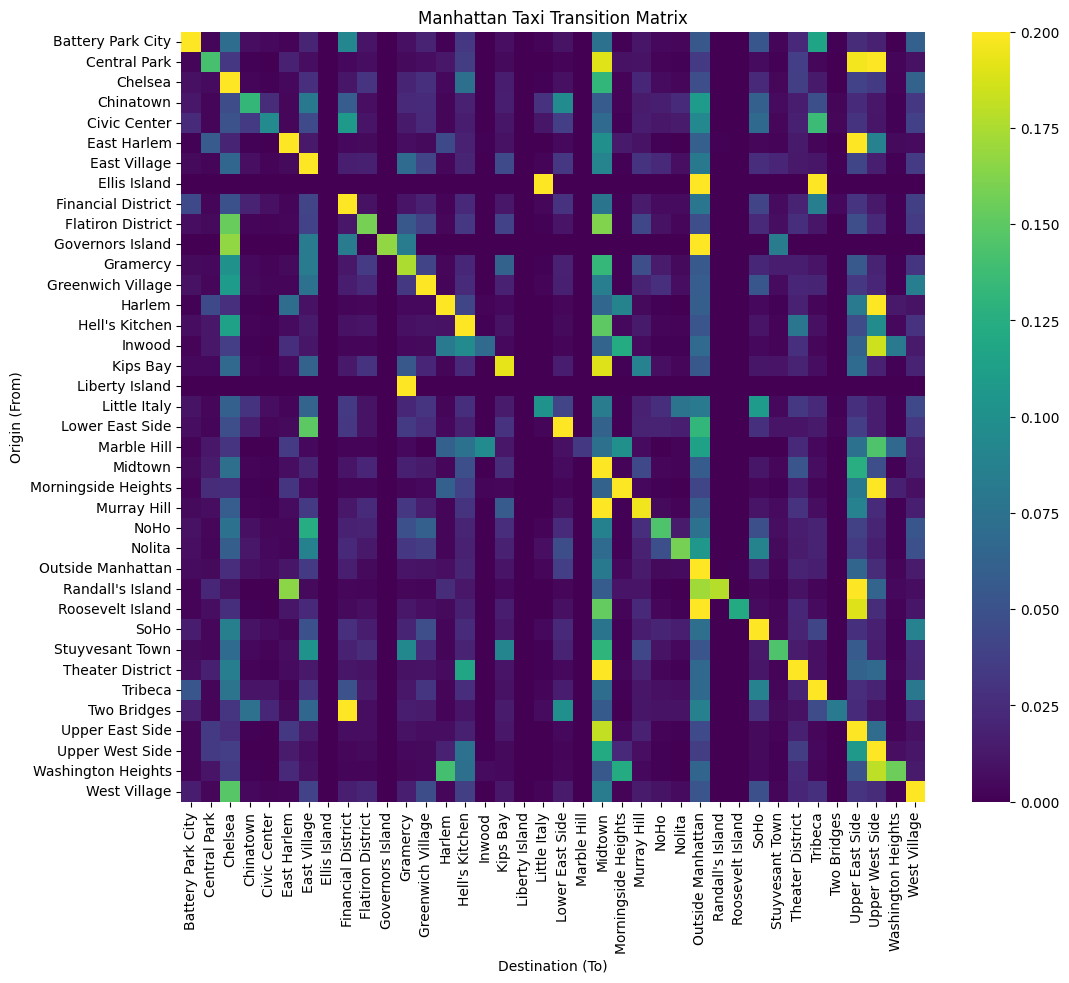

Most common transitions (Probabilities):
From               To               
Liberty Island     Gramercy             1.000000
Outside Manhattan  Outside Manhattan    0.509286
Upper East Side    Upper East Side      0.458643
Upper West Side    Upper West Side      0.423600
Midtown            Midtown              0.360682
dtype: float64


In [14]:
# 6. Plot the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(T, cmap="viridis", vmax=0.2) 
plt.title("Manhattan Taxi Transition Matrix")
plt.xlabel("Destination (To)")
plt.ylabel("Origin (From)")
plt.show()

# Show the most common specific routes
print("Most common transitions (Probabilities):")
print(T.stack().sort_values(ascending=False).head(5))

"Outside Manhattan -> Outside Manhattan" (0.50): If a cab is outside the city (e.g., at JFK airport), it likely stays there for a bit or does another trip nearby.

"Upper East Side -> Upper East Side" (0.45): This is a huge residential area; lots of short local trips happen here.

"Liberty Island -> Gramercy" (1.0): This likely means there was only one trip recorded starting from Liberty Island in the whole dataset, so the probability is 100% based on that single data point.

Taxicabs are most likely Order 1 Markov Chains because they are "memoryless."

- Order 1 means the next state depends only on the current state.

- Order 2+ would mean the next state depends on where you were 2 or more trips ago.

When a taxi driver drops a passenger off in Hell's Kitchen, the destination of their next passenger depends entirely on who hails them right there in Hell's Kitchen. The new passenger doesn't know that the driver came from Wall Street or the Airport before that. The history is "forgotten" the moment the cab becomes empty; only the current location matters for the next trip.

In [21]:
start_node = "Hell's Kitchen"
trips_to_check = [2, 3, 5, 10]

for n in trips_to_check:
    T_n_values = np.linalg.matrix_power(T.values, n)
    
    T_n = pd.DataFrame(T_n_values, index=T.index, columns=T.columns)
    
    forecast = T_n.loc[start_node].sort_values(ascending=False)
    
    print(f"\nAfter {n} trips, most likely locations:")
    print(forecast.head(3))



After 2 trips, most likely locations:
To
Midtown           0.17254
Hell's Kitchen    0.11919
Chelsea           0.10868
Name: Hell's Kitchen, dtype: float64

After 3 trips, most likely locations:
To
Midtown            0.172649
Upper East Side    0.107976
Chelsea            0.097194
Name: Hell's Kitchen, dtype: float64

After 5 trips, most likely locations:
To
Midtown              0.169343
Upper East Side      0.120441
Outside Manhattan    0.099401
Name: Hell's Kitchen, dtype: float64

After 10 trips, most likely locations:
To
Midtown              0.167838
Upper East Side      0.121963
Outside Manhattan    0.102797
Name: Hell's Kitchen, dtype: float64


In [19]:
state = pd.Series(1/len(T.columns), index=T.columns)

for i in range(100):
    new_state = state.dot(T)
    
    diff = np.abs(new_state - state).sum()
    if diff < 1e-6:
        print(f"Converged after {i} iterations.")
        state = new_state
        break
    state = new_state

print("\nTop 10 Neighborhoods where cabs spend the most time:")
print(state.sort_values(ascending=False).head(10))


Converged after 22 iterations.

Top 10 Neighborhoods where cabs spend the most time:
To
Midtown              0.167748
Upper East Side      0.121838
Outside Manhattan    0.102952
Chelsea              0.086153
Upper West Side      0.078541
Hell's Kitchen       0.053318
East Village         0.038700
Theater District     0.038064
West Village         0.036554
Murray Hill          0.028498
dtype: float64


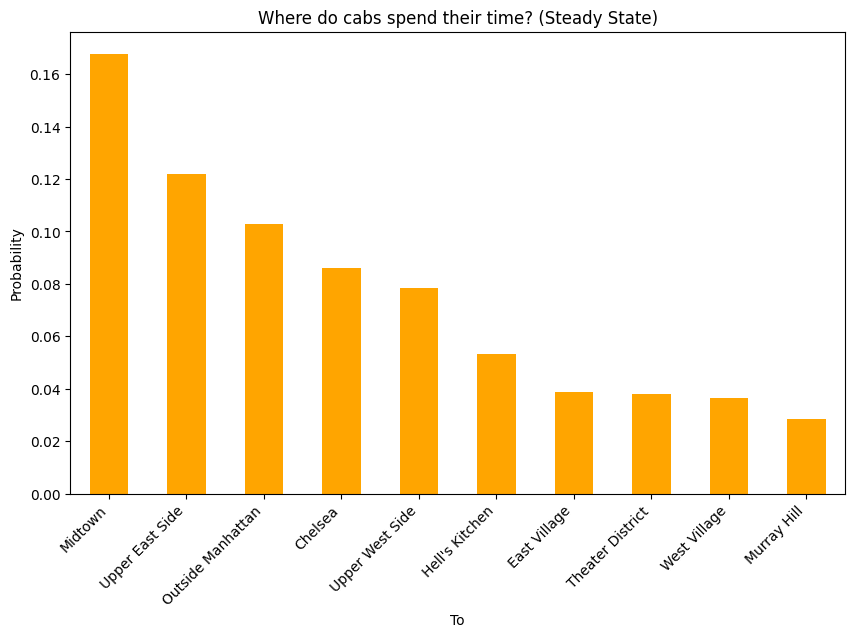

In [20]:
plt.figure(figsize=(10, 6))
state.sort_values(ascending=False).head(10).plot(kind='bar', color='orange')
plt.title("Where do cabs spend their time? (Steady State)")
plt.ylabel("Probability")
plt.xticks(rotation=45, ha='right')
plt.show()